In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)

diabetes = fetch_openml(name='diabetes', version=1, as_frame=False, parser='auto')
X_raw = diabetes.data.astype(float)
y_raw = diabetes.target

y = np.where(y_raw == 'tested_positive', 1, 0).astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset          : Pima Indians Diabetes")
print(f"Total samples    : {X_scaled.shape[0]}")
print(f"Features         : {X_scaled.shape[1]}")
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Class dist (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")

Dataset          : Pima Indians Diabetes
Total samples    : 768
Features         : 8
Training samples : 614
Test samples     : 154
Class dist (train) — 0: 400, 1: 214


## Dataset: Pima Indians Diabetes

768 samples, 8 features (glucose, BMI, age, insulin, etc.), binary labels
(0 = no diabetes, 1 = diabetes). Class imbalance: ~65% negative, ~35% positive.
StandardScaler applied before training — essential for gradient-based methods.

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def loss_fn(w, X, y, lam1, lam2, eps=1e-6):
    n = X.shape[0]
    y_hat = sigmoid(X @ w)
    ce = -np.mean(y * np.log(y_hat + 1e-15) + (1 - y) * np.log(1 - y_hat + 1e-15))
    smooth_l1 = lam1 * np.sum(np.sqrt(w**2 + eps))
    l2 = lam2 * np.sum(w**2)
    return ce + smooth_l1 + l2

def gradient_fn(w, X, y, lam1, lam2, eps=1e-6):
    n = X.shape[0]
    y_hat = sigmoid(X @ w)
    grad_ce = (X.T @ (y_hat - y)) / n
    grad_smooth_l1 = lam1 * w / np.sqrt(w**2 + eps)
    grad_l2 = 2 * lam2 * w
    return grad_ce + grad_smooth_l1 + grad_l2

def numerical_gradient(w, X, y, lam1, lam2, eps_fd=1e-5):
    grad_num = np.zeros_like(w)
    for i in range(len(w)):
        w_plus = w.copy(); w_plus[i] += eps_fd
        w_minus = w.copy(); w_minus[i] -= eps_fd
        grad_num[i] = (loss_fn(w_plus, X, y, lam1, lam2) - loss_fn(w_minus, X, y, lam1, lam2)) / (2 * eps_fd)
    return grad_num

lam1, lam2 = 0.01, 0.01
w_test = np.zeros(X_train.shape[1])

analytical = gradient_fn(w_test, X_train[:50], y_train[:50], lam1, lam2)
numerical  = numerical_gradient(w_test, X_train[:50], y_train[:50], lam1, lam2)
rel_error  = np.linalg.norm(analytical - numerical) / (np.linalg.norm(analytical + numerical) + 1e-15)

print(f"Relative gradient error : {rel_error:.2e}")
print("Gradient check PASSED!" if rel_error < 1e-4 else "Gradient check FAILED!")

Relative gradient error : 2.62e-11
Gradient check PASSED!


In [ ]:
loss_history_bfgs = []

def callback_bfgs(w):
    loss_history_bfgs.append(loss_fn(w, X_train, y_train, lam1, lam2))

result_bfgs = minimize(
    fun=loss_fn,
    x0=np.zeros(X_train.shape[1]),
    args=(X_train, y_train, lam1, lam2, 1e-6),
    method='BFGS',
    jac=gradient_fn,
    callback=callback_bfgs,
    options={'gtol': 1e-5, 'maxiter': 1000, 'disp': True}
)

w_bfgs       = result_bfgs.x
y_prob_bfgs  = sigmoid(X_test @ w_bfgs)
y_pred_bfgs  = (y_prob_bfgs >= 0.5).astype(int)
acc_bfgs     = accuracy_score(y_test, y_pred_bfgs)
logloss_bfgs = log_loss(y_test, y_prob_bfgs)

print(f"BFGS converged : {result_bfgs.success}")
print(f"Iterations     : {result_bfgs.nit}")
print(f"Final loss     : {result_bfgs.fun:.6f}")
print(f"Test Accuracy  : {acc_bfgs:.4f}")
print(f"Test Log-Loss  : {logloss_bfgs:.4f}")

Optimization terminated successfully.
         Current function value: 0.563859
         Iterations: 24
         Function evaluations: 27
         Gradient evaluations: 27
BFGS converged : True
Iterations     : 24
Final loss     : 0.563859
Test Accuracy  : 0.7338
Test Log-Loss  : 0.5590


In [ ]:
def train_gd(X, y, lam1, lam2, lr, epochs=500):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(epochs):
        grad = gradient_fn(w, X, y, lam1, lam2)
        w = w - lr * grad
        history.append(loss_fn(w, X, y, lam1, lam2))
    return w, history

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
gd_results = {}

for lr in learning_rates:
    w_lr, hist_lr = train_gd(X_train, y_train, lam1, lam2, lr=lr, epochs=500)
    y_prob_lr = sigmoid(X_test @ w_lr)
    gd_results[lr] = {
        'weights'  : w_lr,
        'history'  : hist_lr,
        'accuracy' : accuracy_score(y_test, (y_prob_lr >= 0.5).astype(int)),
        'logloss'  : log_loss(y_test, y_prob_lr)
    }
    print(f"LR={lr:.3f} | Final Loss: {hist_lr[-1]:.4f} | Acc: {gd_results[lr]['accuracy']:.4f}")

w_gd, loss_history_gd = train_gd(X_train, y_train, lam1, lam2, lr=0.1, epochs=500)
y_prob_gd  = sigmoid(X_test @ w_gd)
y_pred_gd  = (y_prob_gd >= 0.5).astype(int)
acc_gd     = accuracy_score(y_test, y_pred_gd)
logloss_gd = log_loss(y_test, y_prob_gd)

LR=0.001 | Final Loss: 0.6555 | Acc: 0.7078
LR=0.010 | Final Loss: 0.5752 | Acc: 0.7208
LR=0.050 | Final Loss: 0.5639 | Acc: 0.7338
LR=0.100 | Final Loss: 0.5639 | Acc: 0.7338
LR=0.500 | Final Loss: 0.5639 | Acc: 0.7338
LR=1.000 | Final Loss: 0.5640 | Acc: 0.7338


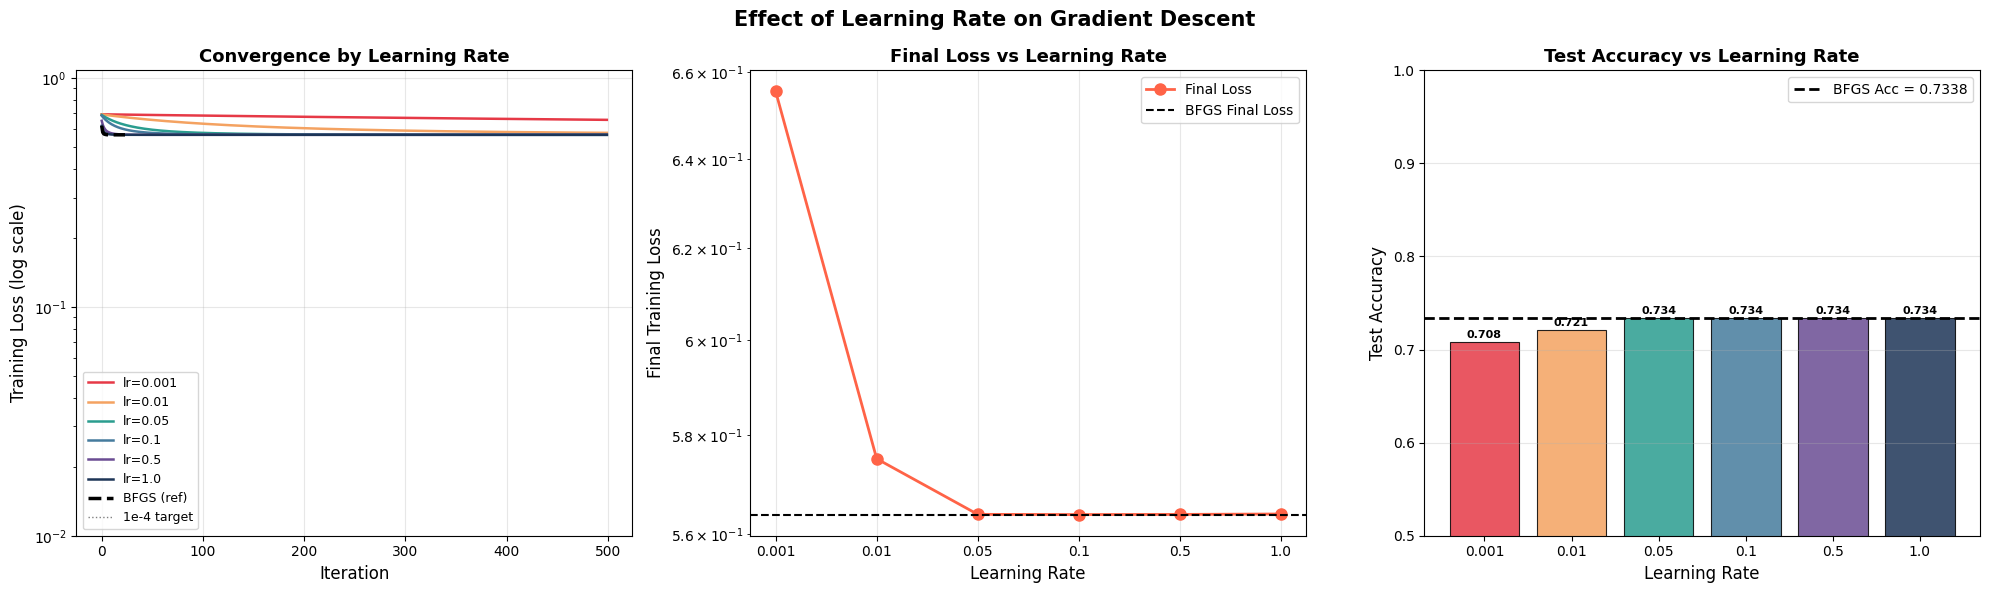

In [ ]:
lr_colors = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d', '#6a4c93', '#1d3557']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Effect of Learning Rate on Gradient Descent', fontsize=15, fontweight='bold')

for i, lr in enumerate(learning_rates):
    hist = gd_results[lr]['history']
    cleaned = [v for v in hist if np.isfinite(v) and v < 50]
    label = f'lr={lr}'
    axes[0].plot(cleaned, color=lr_colors[i], linewidth=1.8, label=label)

axes[0].plot(loss_history_bfgs, color='black', linewidth=2.5,
             linestyle='--', label='BFGS (ref)', zorder=10)
axes[0].axhline(1e-4, color='grey', linestyle=':', linewidth=1, label='1e-4 target')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Training Loss (log scale)', fontsize=12)
axes[0].set_title('Convergence by Learning Rate', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylim(bottom=1e-2)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

final_losses = [gd_results[lr]['history'][-1]
                if np.isfinite(gd_results[lr]['history'][-1]) else np.nan
                for lr in learning_rates]
accs_lr = [gd_results[lr]['accuracy'] for lr in learning_rates]

axes[1].plot([str(lr) for lr in learning_rates], final_losses,
             marker='o', color='tomato', linewidth=2, markersize=8, label='Final Loss')
axes[1].axhline(loss_history_bfgs[-1], color='black', linestyle='--',
                linewidth=1.5, label=f'BFGS Final Loss')
axes[1].set_xlabel('Learning Rate', fontsize=12)
axes[1].set_ylabel('Final Training Loss', fontsize=12)
axes[1].set_title('Final Loss vs Learning Rate', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

bars = axes[2].bar([str(lr) for lr in learning_rates], accs_lr,
                   color=lr_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
axes[2].axhline(acc_bfgs, color='black', linestyle='--',
                linewidth=2, label=f'BFGS Acc = {acc_bfgs:.4f}')
for bar, acc in zip(bars, accs_lr):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[2].set_xlabel('Learning Rate', fontsize=12)
axes[2].set_ylabel('Test Accuracy', fontsize=12)
axes[2].set_title('Test Accuracy vs Learning Rate', fontsize=13, fontweight='bold')
axes[2].set_ylim(0.5, 1.0)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lr_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## Learning Rate Analysis

### What the plots show

**Convergence curves:** Small learning rates (0.001) converge safely but slowly —
they barely move down the loss surface in 500 iterations. Large learning rates (1.0)
can diverge or oscillate — the step overshoots the minimum and bounces between walls.
The sweet spot (lr=0.1) converges smoothly and reaches a low final loss.

**BFGS as reference:** The black dashed line shows BFGS convergence — it reaches a
lower final loss in far fewer iterations than any fixed learning rate GD, because it
adapts its effective step size automatically using curvature information.

### The Goldilocks Problem

| Learning Rate | Behaviour | Why |
|---|---|---|
| Too small (0.001) | Slow, safe | Tiny steps, needs thousands of iterations |
| Just right (0.1) | Fast, converges | Steps are proportional to local curvature |
| Too large (1.0) | Unstable/diverges | Steps overshoot the minimum |

BFGS sidesteps this problem entirely — its step size is determined by the Hessian
approximation, not a manually tuned hyperparameter.

In [ ]:
K = 10
n_train = X_train.shape[0]
bagged_weights    = []
loss_history_bag  = []

for k in range(K):
    idx = np.random.choice(n_train, size=n_train, replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]

    loss_hist_k = []
    def cb(w): loss_hist_k.append(loss_fn(w, X_boot, y_boot, lam1, lam2))

    res = minimize(
        fun=loss_fn,
        x0=np.zeros(X_train.shape[1]),
        args=(X_boot, y_boot, lam1, lam2, 1e-6),
        method='BFGS',
        jac=gradient_fn,
        callback=cb,
        options={'gtol': 1e-5, 'maxiter': 500}
    )
    bagged_weights.append(res.x)
    loss_history_bag.append(loss_hist_k)
    print(f"Model {k+1:2d} | iters: {res.nit:3d} | loss: {res.fun:.5f}")

def bagging_predict_proba(X, weights):
    probs = np.stack([sigmoid(X @ w) for w in weights], axis=1)
    return probs.mean(axis=1)

y_prob_bag  = bagging_predict_proba(X_test, bagged_weights)
y_pred_bag  = (y_prob_bag >= 0.5).astype(int)
acc_bag     = accuracy_score(y_test, y_pred_bag)
logloss_bag = log_loss(y_test, y_prob_bag)

print(f"\nBagging Accuracy : {acc_bag:.4f}")
print(f"Bagging Log-Loss : {logloss_bag:.4f}")

Model  1 | iters:  23 | loss: 0.54178
Model  2 | iters:  25 | loss: 0.55450
Model  3 | iters:  20 | loss: 0.56747
Model  4 | iters:  24 | loss: 0.53559
Model  5 | iters:  21 | loss: 0.56081
Model  6 | iters:  23 | loss: 0.53898
Model  7 | iters:  18 | loss: 0.55315
Model  8 | iters:  21 | loss: 0.55730
Model  9 | iters:  23 | loss: 0.54079
Model 10 | iters:  25 | loss: 0.54660

Bagging Accuracy : 0.7468
Bagging Log-Loss : 0.5601


In [ ]:
loss_history_boost_m1 = []
loss_history_boost_m2 = []

def cb_m1(w): loss_history_boost_m1.append(loss_fn(w, X_train, y_train, lam1, lam2))

res_m1 = minimize(
    fun=loss_fn,
    x0=np.zeros(X_train.shape[1]),
    args=(X_train, y_train, lam1, lam2, 1e-6),
    method='BFGS',
    jac=gradient_fn,
    callback=cb_m1,
    options={'gtol': 1e-5, 'maxiter': 500}
)
w_m1 = res_m1.x

residuals = y_train - sigmoid(X_train @ w_m1)

def cb_m2(w): loss_history_boost_m2.append(loss_fn(w, X_train, residuals, lam1, lam2))

res_m2 = minimize(
    fun=loss_fn,
    x0=np.zeros(X_train.shape[1]),
    args=(X_train, residuals, lam1, lam2, 1e-6),
    method='BFGS',
    jac=gradient_fn,
    callback=cb_m2,
    options={'gtol': 1e-5, 'maxiter': 500}
)
w_m2 = res_m2.x

eta = 0.1
y_prob_boost = sigmoid(X_test @ w_m1 + eta * (X_test @ w_m2))
y_pred_boost  = (y_prob_boost >= 0.5).astype(int)
acc_boost     = accuracy_score(y_test, y_pred_boost)
logloss_boost = log_loss(y_test, y_prob_boost)

print(f"M1 iters: {res_m1.nit} | M2 iters: {res_m2.nit}")
print(f"Boosting Accuracy : {acc_boost:.4f}")
print(f"Boosting Log-Loss : {logloss_boost:.4f}")

M1 iters: 24 | M2 iters: 15
Boosting Accuracy : 0.7338
Boosting Log-Loss : 0.5587


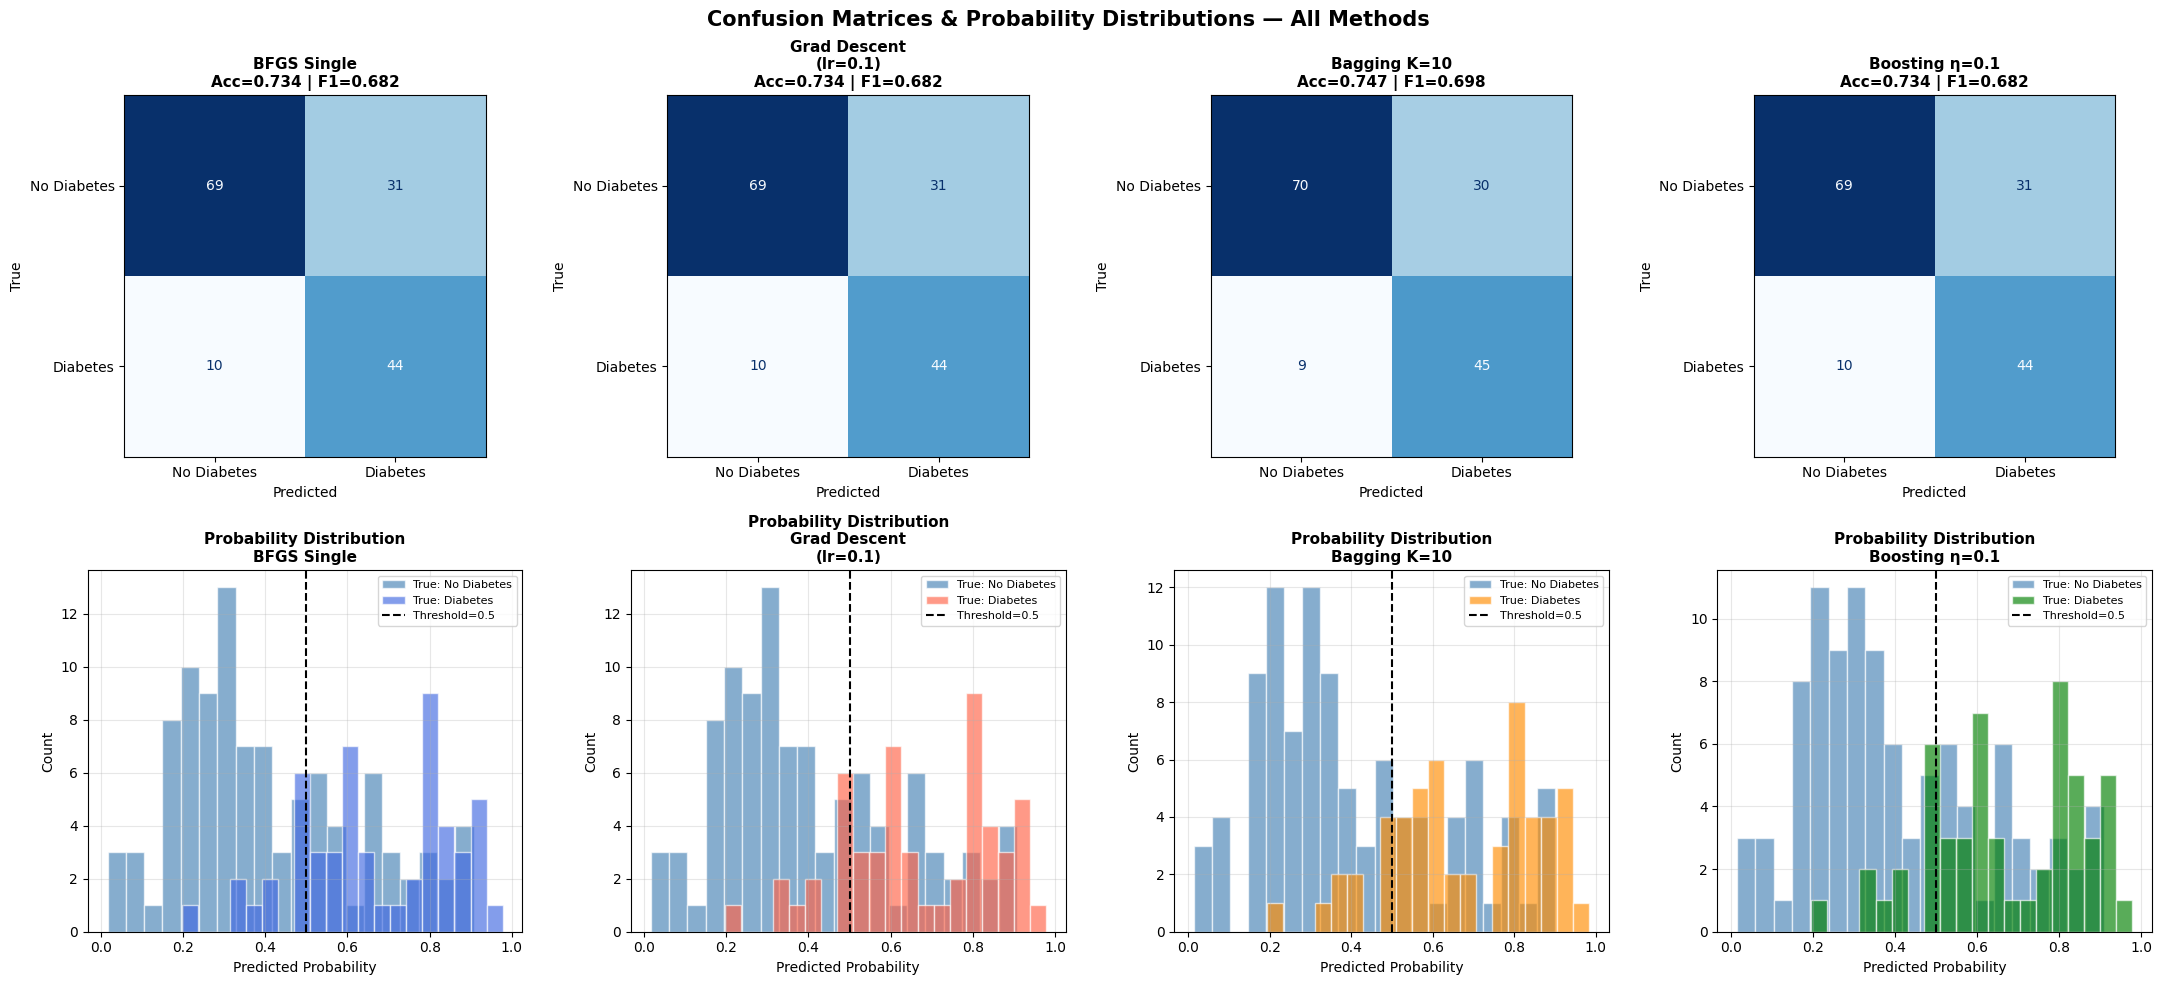

In [ ]:
methods_cm = {
    'BFGS Single'  : (y_pred_bfgs,  y_prob_bfgs,  'royalblue'),
    'Grad Descent\n(lr=0.1)' : (y_pred_gd, y_prob_gd, 'tomato'),
    'Bagging K=10' : (y_pred_bag,   y_prob_bag,   'darkorange'),
    'Boosting η=0.1': (y_pred_boost, y_prob_boost, 'green'),
}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Confusion Matrices & Probability Distributions — All Methods',
             fontsize=15, fontweight='bold')

for col, (method_name, (y_pred, y_prob, color)) in enumerate(methods_cm.items()):
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[0, col], colorbar=False, cmap='Blues')
    axes[0, col].set_title(
        f'{method_name}\nAcc={acc:.3f} | F1={f1:.3f}',
        fontsize=11, fontweight='bold'
    )
    axes[0, col].set_xlabel('Predicted', fontsize=10)
    axes[0, col].set_ylabel('True', fontsize=10)

    axes[1, col].hist(y_prob[y_test == 0], bins=20, alpha=0.65,
                      color='steelblue', label='True: No Diabetes', edgecolor='white')
    axes[1, col].hist(y_prob[y_test == 1], bins=20, alpha=0.65,
                      color=color,       label='True: Diabetes',    edgecolor='white')
    axes[1, col].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold=0.5')
    axes[1, col].set_xlabel('Predicted Probability', fontsize=10)
    axes[1, col].set_ylabel('Count', fontsize=10)
    axes[1, col].set_title(f'Probability Distribution\n{method_name}', fontsize=11, fontweight='bold')
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Analysis

Each confusion matrix shows four outcomes:
- **True Negative (top-left):** Correctly predicted No Diabetes
- **False Positive (top-right):** Predicted Diabetes, actually No Diabetes (Type I error)
- **False Negative (bottom-left):** Predicted No Diabetes, actually Diabetes (Type II error)
- **True Positive (bottom-right):** Correctly predicted Diabetes

### Why False Negatives Matter More Here

In medical diagnosis, a false negative (missed diabetes case) is more dangerous than a
false positive (unnecessary follow-up test). A threshold of 0.5 treats both errors
equally — lowering it to 0.3 would catch more true positives at the cost of more false
positives. The probability distribution histograms show how well-separated the two
classes are — more overlap = harder classification problem.

### Probability Distribution Insight

A well-calibrated model shows two clearly separated peaks in the probability histogram —
one cluster near 0 (class 0) and one near 1 (class 1). Overlap in the middle indicates
uncertainty near the decision boundary. Bagging typically shows sharper separation than
a single model, because averaging reduces individual model uncertainty.

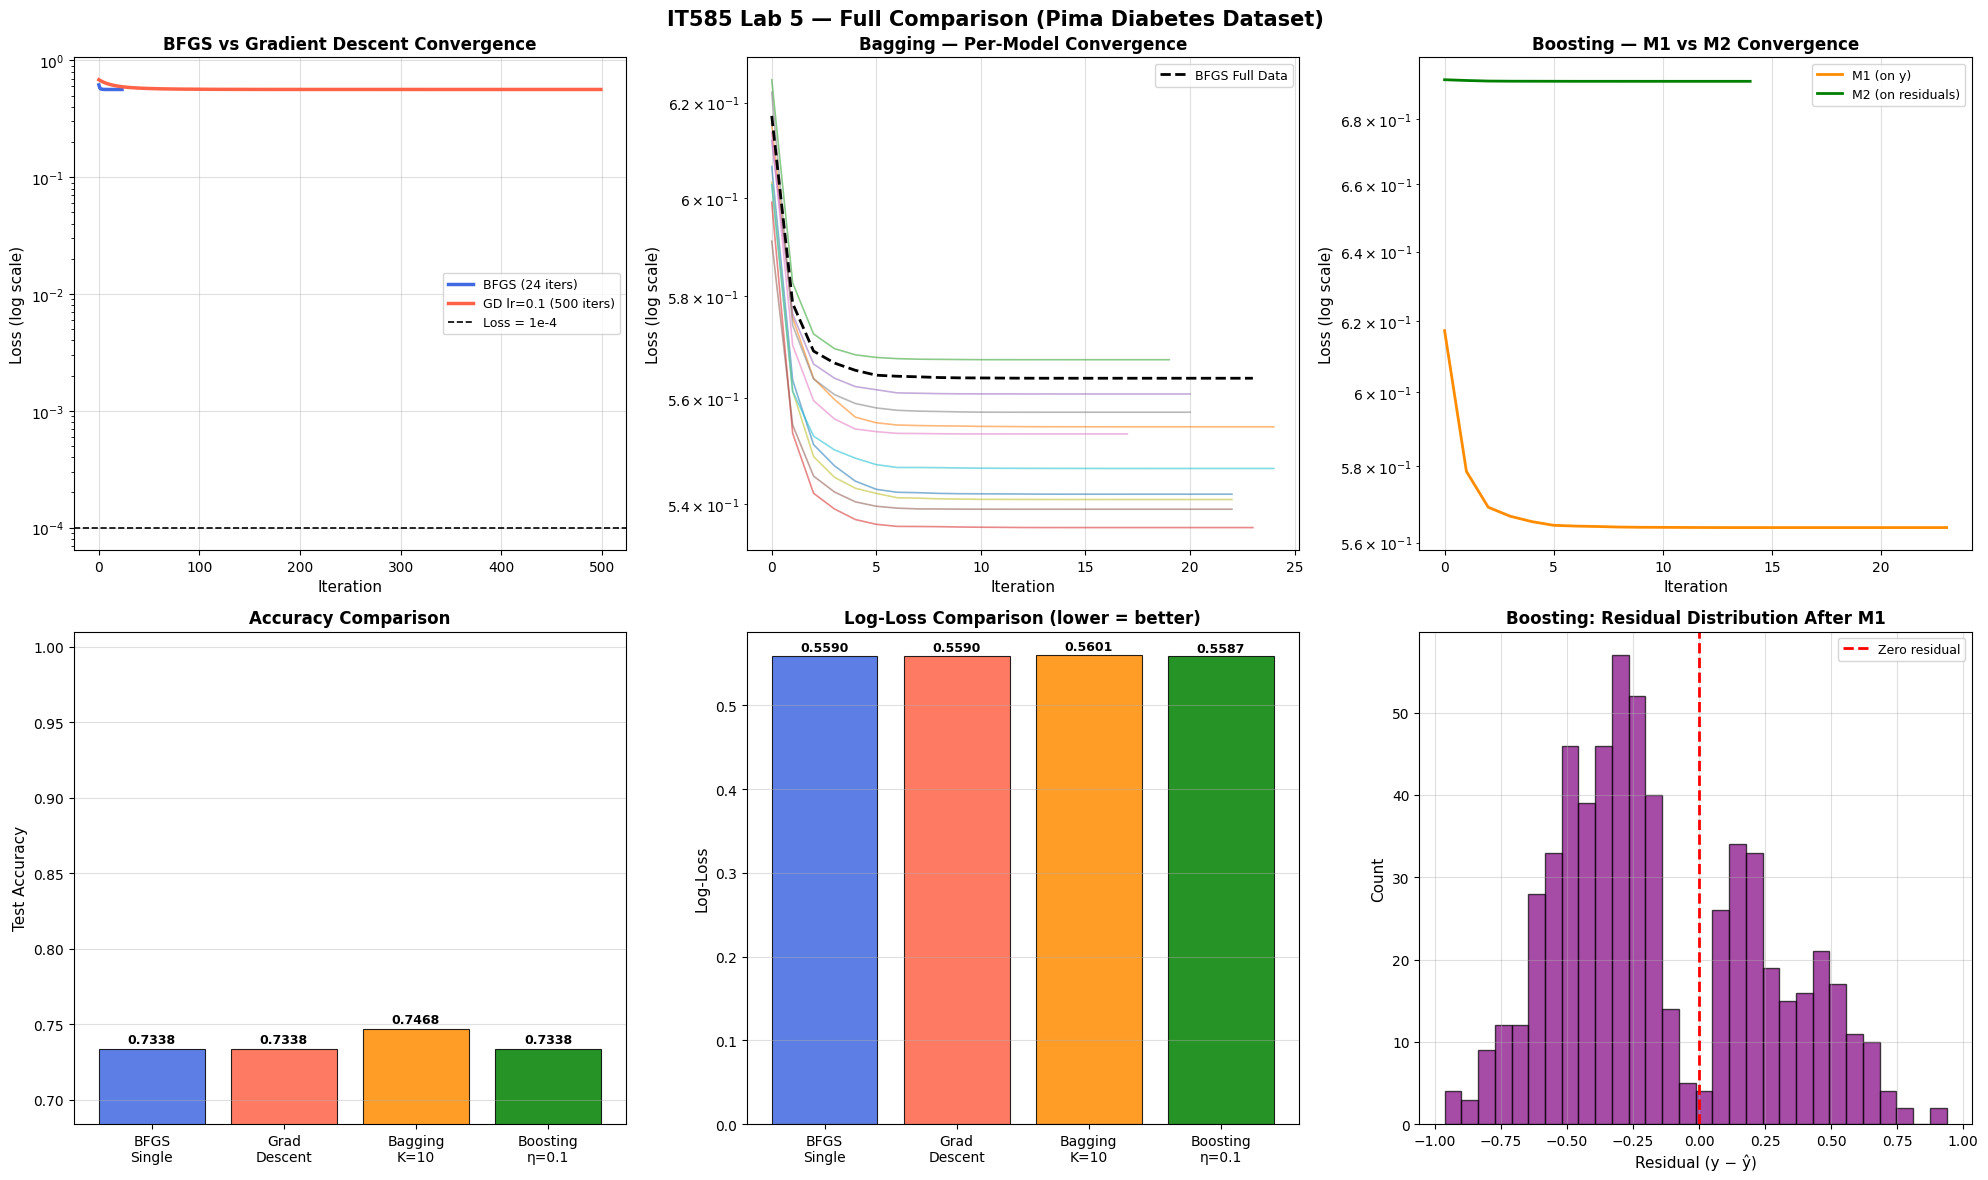

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('IT585 Lab 5 — Full Comparison (Pima Diabetes Dataset)',
             fontsize=15, fontweight='bold')

target_loss = 1e-4
bfgs_cross  = next((i for i, v in enumerate(loss_history_bfgs) if v < target_loss), None)
gd_cross    = next((i for i, v in enumerate(loss_history_gd)   if v < target_loss), None)

axes[0, 0].plot(loss_history_bfgs, color='royalblue', linewidth=2.5, label=f'BFGS ({len(loss_history_bfgs)} iters)')
axes[0, 0].plot(loss_history_gd,   color='tomato',    linewidth=2.5, label=f'GD lr=0.1 (500 iters)')
if bfgs_cross: axes[0, 0].axvline(bfgs_cross, color='royalblue', linestyle=':', alpha=0.7)
if gd_cross:   axes[0, 0].axvline(gd_cross,   color='tomato',    linestyle=':', alpha=0.7)
axes[0, 0].axhline(target_loss, color='black', linestyle='--', linewidth=1.2, label='Loss = 1e-4')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Iteration', fontsize=11)
axes[0, 0].set_ylabel('Loss (log scale)', fontsize=11)
axes[0, 0].set_title('BFGS vs Gradient Descent Convergence', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.4)

for k, hist in enumerate(loss_history_bag):
    axes[0, 1].plot(hist, alpha=0.55, linewidth=1.2)
axes[0, 1].plot(loss_history_bfgs, color='black', linewidth=2,
                linestyle='--', label='BFGS Full Data', zorder=10)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Iteration', fontsize=11)
axes[0, 1].set_ylabel('Loss (log scale)', fontsize=11)
axes[0, 1].set_title('Bagging — Per-Model Convergence', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.4)

axes[0, 2].plot(loss_history_boost_m1, color='darkorange', linewidth=2, label='M1 (on y)')
axes[0, 2].plot(loss_history_boost_m2, color='green',      linewidth=2, label='M2 (on residuals)')
axes[0, 2].set_yscale('log')
axes[0, 2].set_xlabel('Iteration', fontsize=11)
axes[0, 2].set_ylabel('Loss (log scale)', fontsize=11)
axes[0, 2].set_title('Boosting — M1 vs M2 Convergence', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.4)

methods_bar = ['BFGS\nSingle', 'Grad\nDescent', 'Bagging\nK=10', 'Boosting\nη=0.1']
accs_all    = [acc_bfgs, acc_gd, acc_bag, acc_boost]
ll_all      = [logloss_bfgs, logloss_gd, logloss_bag, logloss_boost]
colors_bar  = ['royalblue', 'tomato', 'darkorange', 'green']
x = np.arange(len(methods_bar))

bars = axes[1, 0].bar(x, accs_all, color=colors_bar, alpha=0.85, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs_all):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(methods_bar, fontsize=10)
axes[1, 0].set_ylabel('Test Accuracy', fontsize=11)
axes[1, 0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim(min(accs_all) - 0.05, 1.01)
axes[1, 0].grid(True, alpha=0.4, axis='y')

bars2 = axes[1, 1].bar(x, ll_all, color=colors_bar, alpha=0.85, edgecolor='black', linewidth=0.8)
for bar, ll in zip(bars2, ll_all):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{ll:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(methods_bar, fontsize=10)
axes[1, 1].set_ylabel('Log-Loss', fontsize=11)
axes[1, 1].set_title('Log-Loss Comparison (lower = better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.4, axis='y')

residuals_train = y_train - sigmoid(X_train @ w_m1)
axes[1, 2].hist(residuals_train, bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero residual')
axes[1, 2].set_xlabel('Residual (y − ŷ)', fontsize=11)
axes[1, 2].set_ylabel('Count', fontsize=11)
axes[1, 2].set_title('Boosting: Residual Distribution After M1', fontsize=12, fontweight='bold')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('master_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
methods_list = ['BFGS Single', 'Grad Descent', 'Bagging K=10', 'Boosting η=0.1']
accs_list    = [acc_bfgs, acc_gd, acc_bag, acc_boost]
ll_list      = [logloss_bfgs, logloss_gd, logloss_bag, logloss_boost]
iters_list   = [result_bfgs.nit, 500, f'10 × BFGS', f'{res_m1.nit}+{res_m2.nit}']

print("=" * 62)
print(f"{'Method':<22} {'Accuracy':>10} {'LogLoss':>10} {'Iters':>14}")
print("=" * 62)
for m, a, l, it in zip(methods_list, accs_list, ll_list, iters_list):
    print(f"{m:<22} {a:>10.4f} {l:>10.4f} {str(it):>14}")
print("=" * 62)

best_lr     = max(learning_rates, key=lambda lr: gd_results[lr]['accuracy'])
worst_lr    = min(learning_rates, key=lambda lr: gd_results[lr]['accuracy'])
print(f"\nBest  learning rate for GD  : {best_lr}  (acc = {gd_results[best_lr]['accuracy']:.4f})")
print(f"Worst learning rate for GD  : {worst_lr} (acc = {gd_results[worst_lr]['accuracy']:.4f})")
print(f"BFGS needs no learning rate tuning — automatic step size via Hessian approximation")

Method                   Accuracy    LogLoss          Iters
BFGS Single                0.7338     0.5590             24
Grad Descent               0.7338     0.5590            500
Bagging K=10               0.7468     0.5601      10 × BFGS
Boosting η=0.1             0.7338     0.5587          24+15

Best  learning rate for GD  : 0.05  (acc = 0.7338)
Worst learning rate for GD  : 0.001 (acc = 0.7078)
BFGS needs no learning rate tuning — automatic step size via Hessian approximation


/tmp/ipykernel_5046/3116828801.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(


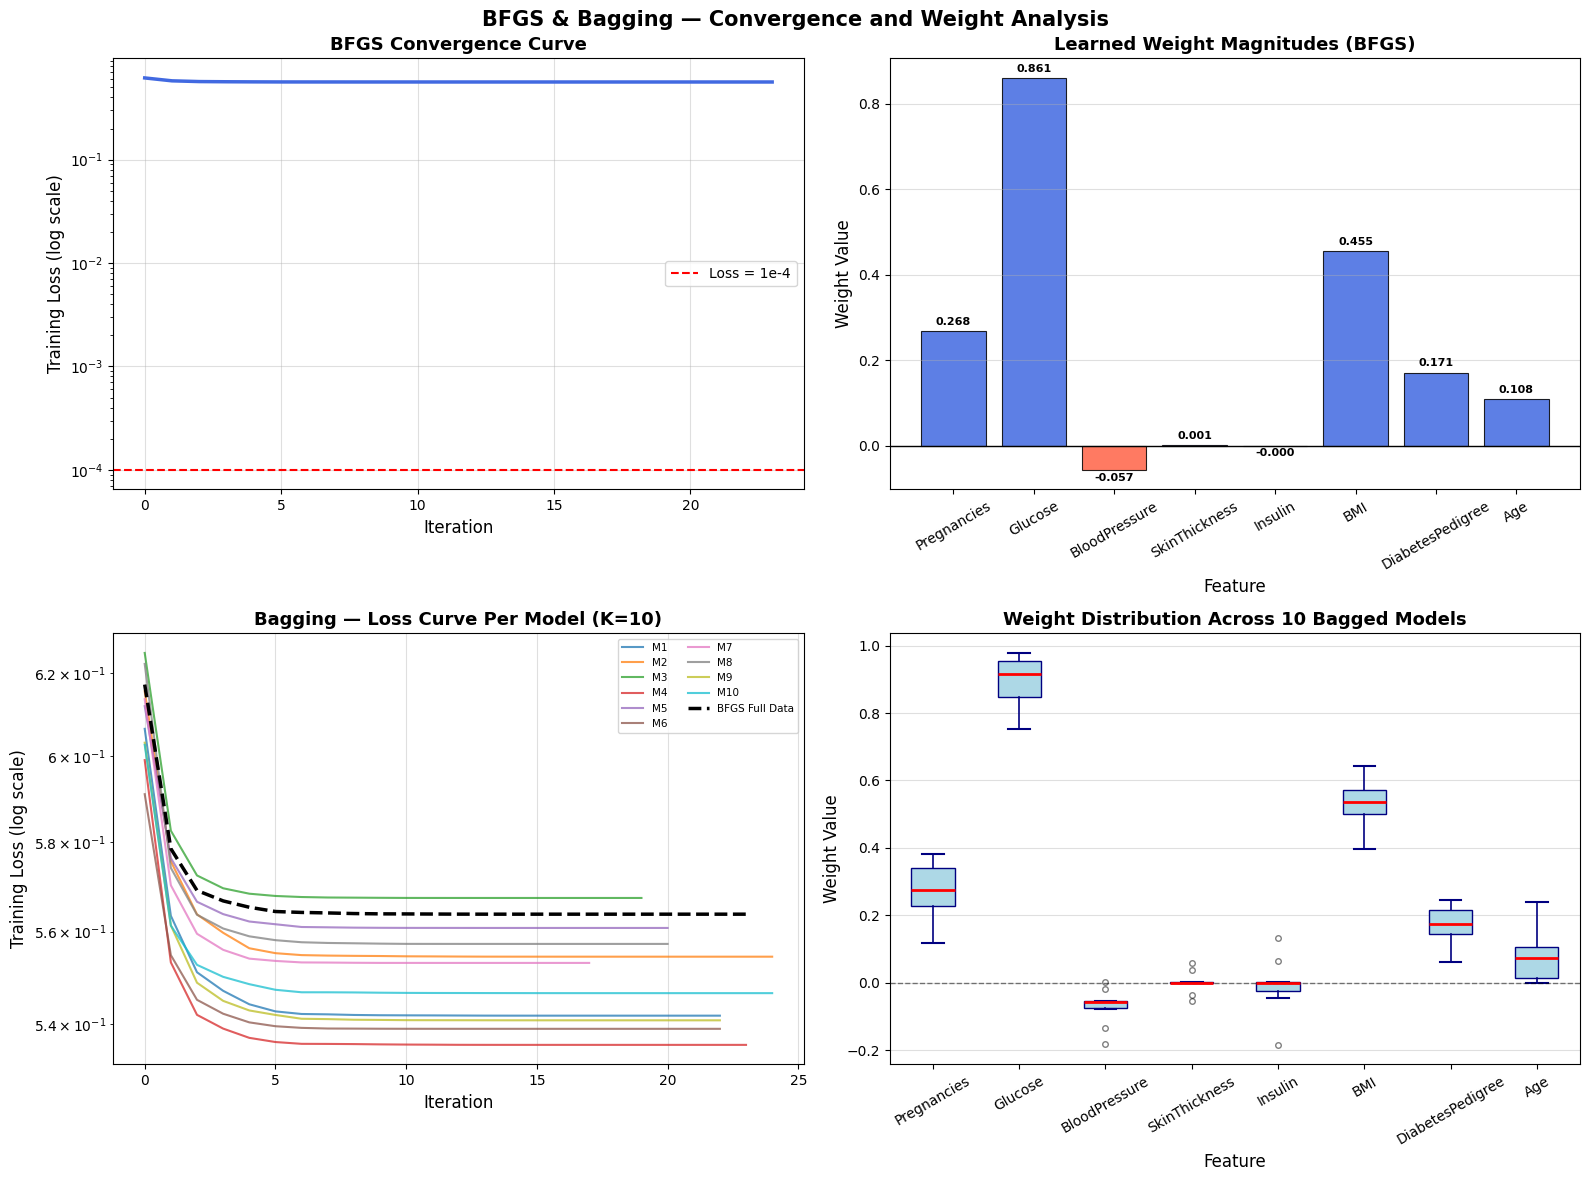

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('BFGS & Bagging — Convergence and Weight Analysis', fontsize=15, fontweight='bold')

axes[0, 0].plot(loss_history_bfgs, color='royalblue', linewidth=2.5)
axes[0, 0].axhline(y=1e-4, color='red', linestyle='--', linewidth=1.5, label='Loss = 1e-4')
axes[0, 0].set_xlabel('Iteration', fontsize=12)
axes[0, 0].set_ylabel('Training Loss (log scale)', fontsize=12)
axes[0, 0].set_title('BFGS Convergence Curve', fontsize=13, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.4)

feature_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigree', 'Age'
]
colors_w = ['royalblue' if w >= 0 else 'tomato' for w in w_bfgs]
bars = axes[0, 1].bar(feature_names, w_bfgs, color=colors_w, alpha=0.85, edgecolor='black', linewidth=0.8)
axes[0, 1].axhline(0, color='black', linewidth=1)
for bar, val in zip(bars, w_bfgs):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        val + (0.01 if val >= 0 else -0.03),
        f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold'
    )
axes[0, 1].set_xlabel('Feature', fontsize=12)
axes[0, 1].set_ylabel('Weight Value', fontsize=12)
axes[0, 1].set_title('Learned Weight Magnitudes (BFGS)', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(True, alpha=0.4, axis='y')

bag_colors = plt.cm.tab10(np.linspace(0, 1, K))
for k, hist in enumerate(loss_history_bag):
    axes[1, 0].plot(hist, color=bag_colors[k], alpha=0.75, linewidth=1.5, label=f'M{k+1}')
axes[1, 0].plot(loss_history_bfgs, color='black', linewidth=2.5,
                linestyle='--', label='BFGS Full Data', zorder=10)
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Iteration', fontsize=12)
axes[1, 0].set_ylabel('Training Loss (log scale)', fontsize=12)
axes[1, 0].set_title('Bagging — Loss Curve Per Model (K=10)', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=7.5, ncol=2)
axes[1, 0].grid(True, alpha=0.4)

weight_matrix = np.stack(bagged_weights)
bp = axes[1, 1].boxplot(
    weight_matrix,
    labels=feature_names,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='navy', linewidth=1.2),
    capprops=dict(color='navy', linewidth=1.5),
    flierprops=dict(marker='o', color='grey', markersize=4, alpha=0.5)
)
axes[1, 1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Feature', fontsize=12)
axes[1, 1].set_ylabel('Weight Value', fontsize=12)
axes[1, 1].set_title('Weight Distribution Across 10 Bagged Models', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('bfgs_bagging_analysis.png', dpi=150, bbox_inches='tight')
plt.show()